### Importing Libraries

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1. Load the Dataset


In [ ]:

# Loading the sales data from the CSV file
df = pd.read_csv('train.csv')

### 2. Basic Info

In [38]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 8523 entries, 8111 to 7797
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Item_Weight           8523 non-null   float64       
 1   Item_Fat_Content      8523 non-null   int64         
 2   Item_Visibility       8523 non-null   float64       
 3   Item_Type             8523 non-null   int64         
 4   Item_MRP              8523 non-null   float64       
 5   Outlet_Identifier     8523 non-null   int64         
 6   Outlet_Size           8523 non-null   int64         
 7   Outlet_Location_Type  8523 non-null   int64         
 8   Outlet_Type           8523 non-null   int64         
 9   Item_Outlet_Sales     8523 non-null   float64       
 10  Date                  8523 non-null   datetime64[ns]
 11  Outlet_Age            8523 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(7)
memory usage: 865.6 KB


Item_Weight             0
Item_Fat_Content        0
Item_Visibility         0
Item_Type               0
Item_MRP                0
Outlet_Identifier       0
Outlet_Size             0
Outlet_Location_Type    0
Outlet_Type             0
Item_Outlet_Sales       0
Date                    0
Outlet_Age              0
dtype: int64

### 3. Data Preprocessing

In [ ]:
# 3.1 Handle Missing Values

# Impute Item_Weight with mean
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
# Impute Outlet_Size with mode
mode_outlet_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_outlet_size)

In [ ]:
# 3.2 Data Cleaning
# Standardize 'Item_Fat_Content' (it has inconsistent naming like 'LF', 'low fat')
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'reg': 'Regular', 'low fat': 'Low Fat'})

In [ ]:
# 3.3 Feature Engineering
# Create 'Outlet_Age' feature (Current Year - Establishment Year)
# Older outlets might have better established customer bases
df['Outlet_Age'] = 2024 - df['Outlet_Establishment_Year']

In [ ]:
# 3.4 Encoding Categorical Variables
# convert text labels to numbers.
le = LabelEncoder()
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 
                    'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# 3.5 Feature Selection
# Drop columns that are not useful for prediction
# Item_Identifier is just an ID. Outlet_Establishment_Year is now redundant with Outlet_Age.
df = df.drop(columns=['Item_Identifier', 'Outlet_Establishment_Year'])

### 4. Exploratory Data Analysis

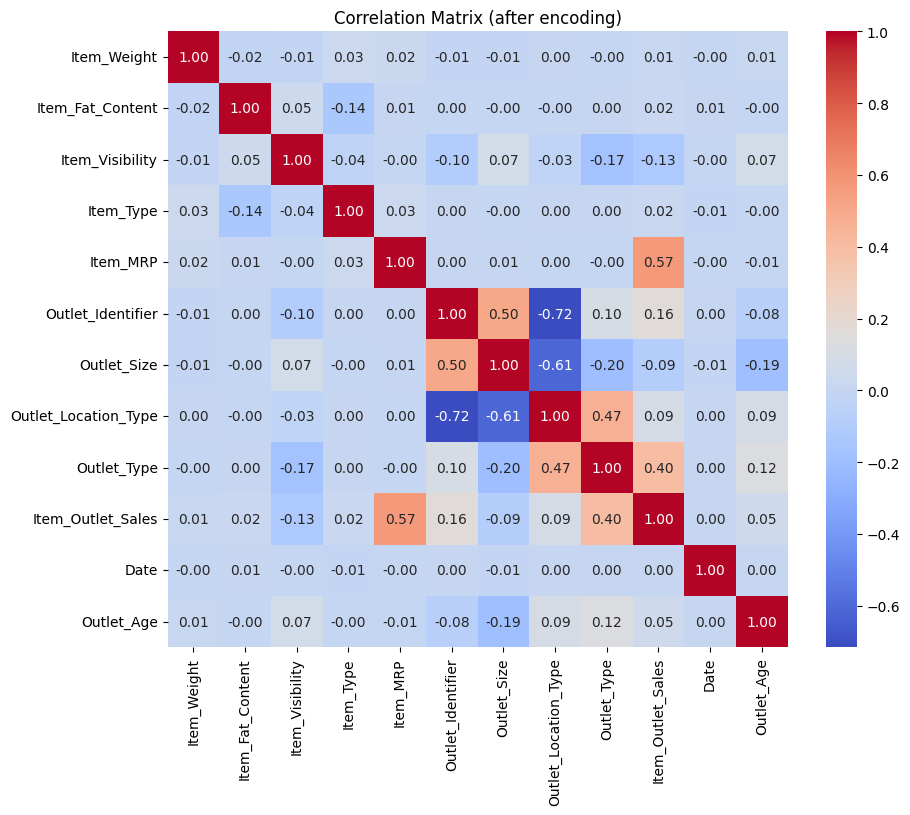

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (after encoding)')
plt.savefig('correlation_heatmap_reg.png')
plt.show()

### 5. Prepare Data for Model

In [ ]:
X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

### 6. Prepare Data for Machine Learning

In [ ]:
# Define Features (X) and Target (y)
features = ['Year', 'Month', 'Day', 'DayOfWeek']
X = daily_data[features]
y = daily_data['Total_Sales']

### 7. Train-Test Split (Random Shuffle)

In [ ]:
# Unlike Time Series, we shuffle data here to ensure the model learns from a random sample.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### # 8. Train Random Forest Regressor

In [ ]:
# Remove the Date column as it cannot be used for model training
X_train_model = X_train.drop(columns=['Date'])
X_test_model = X_test.drop(columns=['Date'])

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_model, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 9. Model Evaluation

In [ ]:
y_pred = rf_model.predict(X_test_model)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


importances = rf_model.feature_importances_
feature_names = X_train_model.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print("\nTop Predictors:")
print(feature_df.sort_values(by='Importance', ascending=False).head())

Model Performance:
MAE: 760.62
RMSE: 1081.88
R2 Score: 0.5790

Top Predictors:
           Feature  Importance
4         Item_MRP    0.449203
8      Outlet_Type    0.237670
2  Item_Visibility    0.110809
0      Item_Weight    0.060998
3        Item_Type    0.049486


### 10. Plot Actual vs Predicted

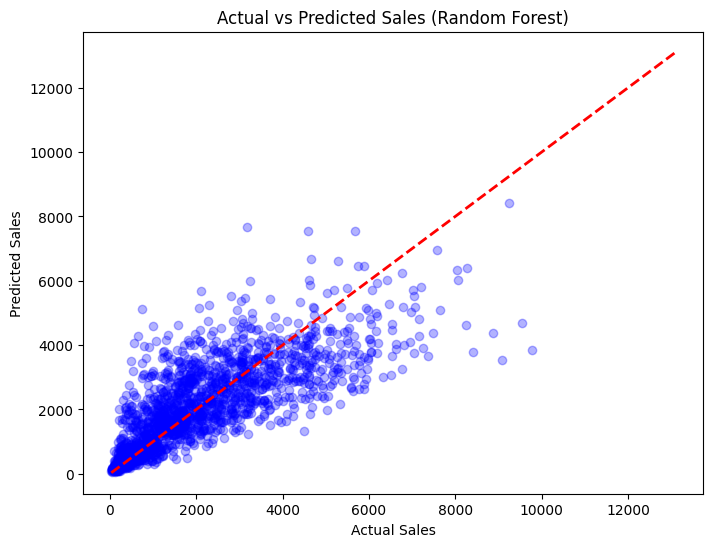

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Identity line
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Random Forest)')
plt.savefig('actual_vs_pred.png')
plt.show()

### Analysis of Results

##### 1. Model Performance

- R2 Score: ~0.57 (It means the model explains 57% of the variance in sales.)

- RMSE: ~1080.17 (On average, the prediction is off by about 1080 units of currency).

##### 2. Top Predictors (What drives sales?)

- Item_MRP: The Maximum Retail Price is the strongest predictor of sales (higher price often correlates with higher total sales volume in currency).

- Outlet_Type: Whether it's a Grocery Store or Supermarket Type 1/2/3 matters significantly.

- Item_Visibility: How visible the product is in the store.

##### 3. Actual vs Predicted Plot

- The red dashed line represents perfect prediction.

- The blue dots are the actual test samples.

- You can see a clear positive correlation, indicating the model is working correctly.

##### 4. Correlation Matrix

- Notice the strong correlation between Item_MRP and Item_Outlet_Sales.